In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [39]:
df=pd.read_csv("emp_data.csv")
df.head()

,Customer_ID,Name,Age,Gender,Department,Monthly_Income,City,Customer_Type,Latitude,Longitude,Purchase_Amount,Feedback
0,1630,Aarav Jadhav,36.0,Female,Finance,110390.0,Ahmednagar,New,17.536043,75.505984,62663.45,Good
1,1789,Neha Sharma,32.0,Female,Operations,39371.0,Ahmednagar,Regular,20.073236,75.947597,31790.01,Excellent
2,1685,Amit Joshi,53.0,Male,Marketing,38204.0,Kolhapur,New,20.852464,75.521740,91180.51,Average
3,1517,Amit Deshmukh,33.0,Female,Data Analytics,50382.0,Nagpur,Premium,20.430885,77.862365,1535.62,Average
4,1530,Rahul Pawar,58.0,Female,Operations,70249.0,Aurangabad,New,17.555342,73.493211,26105.84,Good


In [3]:
df.shape

(1000, 12)

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      1000 non-null   int64  
 1   Name             1000 non-null   str    
 2   Age              1000 non-null   float64
 3   Gender           1000 non-null   str    
 4   Department       1000 non-null   str    
 5   Monthly_Income   1000 non-null   float64
 6   City             1000 non-null   str    
 7   Customer_Type    1000 non-null   str    
 8   Latitude         1000 non-null   float64
 9   Longitude        1000 non-null   float64
 10  Purchase_Amount  1000 non-null   float64
 11  Feedback         1000 non-null   str    
dtypes: float64(5), int64(1), str(6)
memory usage: 136.0 KB


In [41]:
df.describe()           # Numerical Statistics

,Customer_ID,Age,Monthly_Income,Latitude,Longitude,Purchase_Amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,39.740000,68517.750000,19.010508,76.497385,49672.976440
std,288.819436,11.966604,29584.635284,1.421343,2.314239,29194.733881
min,1001.000000,18.000000,15012.000000,16.510429,72.515640,553.320000
25%,1250.750000,30.000000,43851.750000,17.803538,74.439330,24371.052500
50%,1500.500000,40.000000,68650.500000,19.013194,76.473895,48333.705000
75%,1750.250000,50.000000,93431.750000,20.229634,78.469961,74828.420000
max,2000.000000,60.000000,119969.000000,21.499106,80.474739,99995.440000


In [11]:
print("Mean:", df["Monthly_Income"].mean())
print("Median:", df["Monthly_Income"].median())
print("Minimum:", df["Monthly_Income"].min())
print("Maximum:", df["Monthly_Income"].max())
print("Standard Deviation:", df["Monthly_Income"].std())

Mean: 68517.75
Median: 68650.5
Minimum: 15012.0
Maximum: 119969.0
Standard Deviation: 29584.63528362933


In [12]:
df.isnull().sum()

Customer_ID        0
Name               0
Age                0
Gender             0
Department         0
Monthly_Income     0
City               0
Customer_Type      0
Latitude           0
Longitude          0
Purchase_Amount    0
Feedback           0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [21]:
# convert all Customer_Type in upper case
df['Customer_Type']=df['Customer_Type'].str.upper()

In [22]:
df.nunique()      # number of unique value

Customer_ID        1000
Name                201
Age                  43
Gender                2
Department            7
Monthly_Income      981
City                  8
Customer_Type         3
Latitude            995
Longitude           995
Purchase_Amount     991
Feedback              5
dtype: int64

# Age Analysis

In [43]:
print("Average Age:", df["Age"].mean())
print("Median Age:", df["Age"].median())
print("Minimum Age:", df["Age"].min())
print("Maximum Age:", df["Age"].max())

Average Age: 39.74
Median Age: 40.0
Minimum Age: 18.0
Maximum Age: 60.0


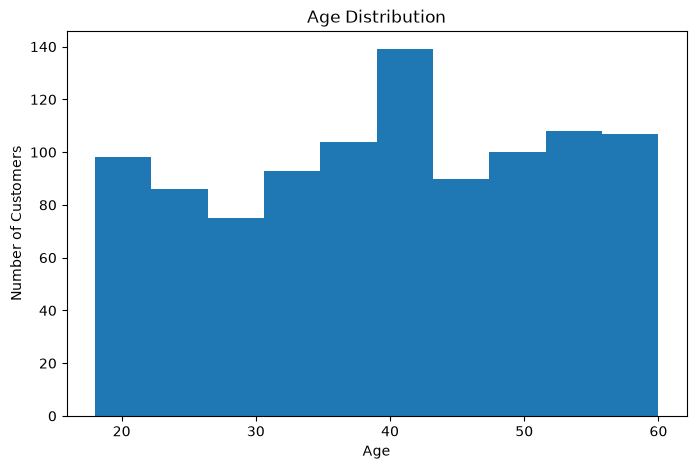

In [44]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=10)

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution")

plt.show()

In [46]:
# Age Group
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 20, 30, 40, 50, 60],
    labels=["Below 20", "21-30", "31-40", "41-50", "51-60"]
)

df["Age_Group"].value_counts().sort_index()

Age_Group
Below 20     54
21-30       205
31-40       255
41-50       250
51-60       236
Name: count, dtype: int64

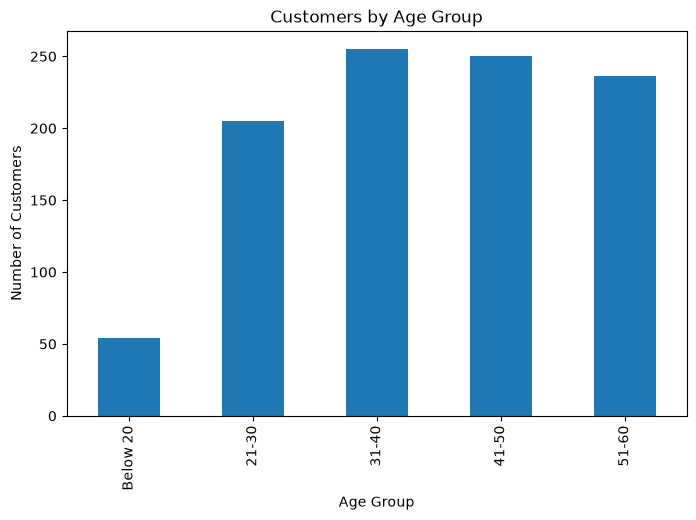

In [47]:
df["Age_Group"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.title("Customers by Age Group")

plt.show()

# Analyze categorical columns

In [15]:
print(df['Gender'].value_counts())
print(df["Department"].value_counts())
print(df["City"].value_counts())
print(df['Customer_Type'].value_counts())
print(df["Feedback"].value_counts())


Gender
Male      512
Female    488
Name: count, dtype: int64
Department
Operations        187
Marketing         145
Data Analytics    143
IT                143
HR                128
Sales             128
Finance           126
Name: count, dtype: int64
City
Ahmednagar    142
Mumbai        130
Nashik        127
Kolhapur      124
Aurangabad    124
Pune          123
Thane         120
Nagpur        110
Name: count, dtype: int64
Customer_Type
Regular    359
Premium    322
New        315
regular      3
premium      1
Name: count, dtype: int64
Feedback
Good         224
Poor         200
Average      196
Excellent    191
Very Good    189
Name: count, dtype: int64


In [16]:
# Analyze income
print(df["Monthly_Income"].describe())

count      1000.000000
mean      68517.750000
std       29584.635284
min       15012.000000
25%       43851.750000
50%       68650.500000
75%       93431.750000
max      119969.000000
Name: Monthly_Income, dtype: float64


In [18]:
# Average income by department
income_department = (
    df.groupby("Department")["Monthly_Income"].mean().sort_values(ascending=False)
)
print(income_department)

Department
Marketing         71919.234483
Data Analytics    70891.437063
Sales             70515.273438
HR                69576.308594
Operations        67792.620321
Finance           66687.583333
IT                62520.332168
Name: Monthly_Income, dtype: float64


In [ ]:
# Customer Type Distribution

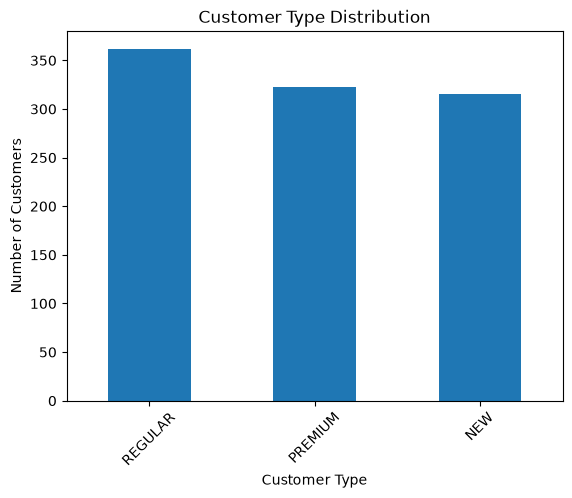

In [26]:
df["Customer_Type"].value_counts().plot(kind="bar")

plt.title("Customer Type Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

# Monthly income Distribution

In [27]:
df

,Customer_ID,Name,Age,Gender,Department,Monthly_Income,City,Customer_Type,Latitude,Longitude,Purchase_Amount,Feedback
0,1630,Aarav Jadhav,36.0,Female,Finance,110390.0,Ahmednagar,NEW,17.536043,75.505984,62663.45,Good
1,1789,Neha Sharma,32.0,Female,Operations,39371.0,Ahmednagar,REGULAR,20.073236,75.947597,31790.01,Excellent
2,1685,Amit Joshi,53.0,Male,Marketing,38204.0,Kolhapur,NEW,20.852464,75.521740,91180.51,Average
3,1517,Amit Deshmukh,33.0,Female,Data Analytics,50382.0,Nagpur,PREMIUM,20.430885,77.862365,1535.62,Average
4,1530,Rahul Pawar,58.0,Female,Operations,70249.0,Aurangabad,NEW,17.555342,73.493211,26105.84,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
995,1107,Meera Chavan,46.0,Male,IT,49671.0,Pune,REGULAR,19.081121,78.961383,17574.52,Poor
996,1271,Sahil Joshi,24.0,Male,Marketing,25490.0,Mumbai,PREMIUM,18.551581,76.760438,17463.15,Very Good
997,1861,Kavya Kulkarni,44.0,Male,Finance,31009.0,Kolhapur,NEW,16.723412,75.077469,41198.81,Poor
998,1436,Riya Patil,20.0,Male,Operations,15868.0,Ahmednagar,REGULAR,18.147135,75.114177,10314.42,Average


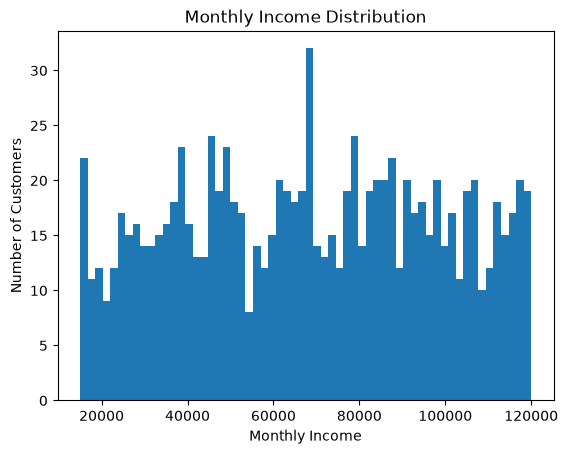

In [31]:
plt.hist(df["Monthly_Income"], bins=60)
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Customers")
plt.show()

In [31]:
df.columns

Index(['Customer_ID', 'Name', 'Age', 'Gender', 'Department', 'Monthly_Income',
       'City', 'Customer_Type', 'Latitude', 'Longitude', 'Purchase_Amount',
       'Feedback'],
      dtype='str')

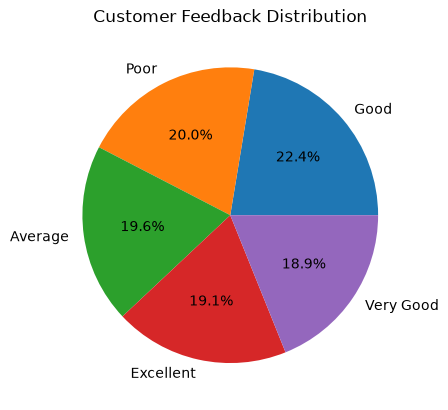

In [32]:
df["Feedback"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.title("Customer Feedback Distribution")
plt.ylabel("")
plt.show()

# Age vs Monthly Income

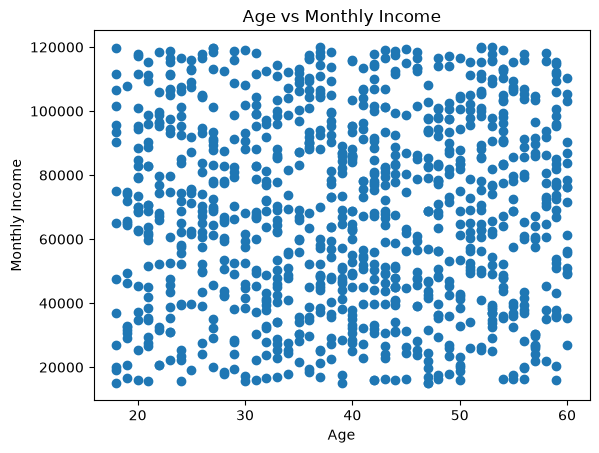

In [46]:
plt.scatter(df["Age"], df["Monthly_Income"])

plt.title("Age vs Monthly Income")
plt.xlabel("Age")
plt.ylabel("Monthly Income")
plt.show()

#  Average Income by Department

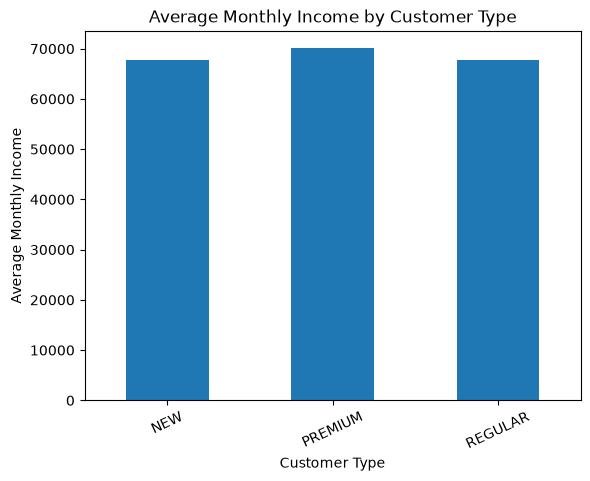

In [33]:
df.groupby("Customer_Type")["Monthly_Income"].mean().plot(kind="bar")

plt.title("Average Monthly Income by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Monthly Income")
plt.xticks(rotation=25)
plt.show()

# Anomalies

In [53]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower)
print("Upper Limit:", upper)
print("Number of anomalies:", len(anomalies))

Q1: 43851.75
Q3: 93431.75
IQR: 49580.0
Lower Limit: -30518.25
Upper Limit: 167801.75
Number of anomalies: 0


In [ ]:
#  Identify Income Anomalies

In [58]:
Q1 = df["Monthly_Income"].quantile(0.25)
Q3 = df["Monthly_Income"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 43851.75
Q3: 93431.75
IQR: 49580.0
Lower Limit: -30518.25
Upper Limit: 167801.75


# Purchase Amount Anomalies

In [61]:
Q1 = df["Purchase_Amount"].quantile(0.25)
Q3 = df["Purchase_Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

purchase_anomalies = df[
    (df["Purchase_Amount"] < lower_limit) |
    (df["Purchase_Amount"] > upper_limit)
]

print("Number of purchase anomalies:", len(purchase_anomalies))


Number of purchase anomalies: 0


In [37]:
# 15. Top 10 Customers by Income

top_income = df[
    ["Customer_ID", "Name", "Monthly_Income"]
].sort_values(
    by="Monthly_Income",
    ascending=False
).head(10)

top_income

,Customer_ID,Name,Monthly_Income
142,1250,Nikhil Kulkarni,119969.0
785,1385,Sneha Pawar,119878.0
257,1524,Karan Shinde,119862.0
191,1757,Isha Chavan,119852.0
303,1808,Meera More,119787.0
986,1459,Amit More,119761.0
123,1729,Sneha Sharma,119590.0
649,1733,Pooja Joshi,119433.0
983,1100,Pooja Sharma,119151.0
764,1878,Riya Sharma,119122.0


In [64]:
# Top 10 Customers by Purchase Amount

top_purchase = df[
    ["Customer_ID", "Name", "Purchase_Amount"]
].sort_values(
    by="Purchase_Amount",
    ascending=False
).head(10)

top_purchase

,Customer_ID,Name,Purchase_Amount
531,1069,Neha Kulkarni,99995.44
604,1256,Akash Chavan,99917.21
943,1991,Vikas Chavan,99905.29
223,1829,Sahil Shinde,99702.45
674,1120,Sahil Chavan,99681.32
312,1833,Kavya Pawar,99443.25
964,1253,Sakshi Deshmukh,99425.08
64,1814,Neha Pawar,99344.95
899,1816,Akash Pawar,99231.75
982,1872,Sahil Patil,99129.19


In [35]:
numeric_columns = [
    "Age",
    "Monthly_Income",
    "Latitude",
    "Longitude",
    "Purchase_Amount"
]

correlation = df[numeric_columns].corr()

print(correlation)

                      Age  Monthly_Income  Latitude  Longitude  \
Age              1.000000        0.016076  0.002000  -0.061050   
Monthly_Income   0.016076        1.000000 -0.031255  -0.015078   
Latitude         0.002000       -0.031255  1.000000  -0.045176   
Longitude       -0.061050       -0.015078 -0.045176   1.000000   
Purchase_Amount -0.001452       -0.000142  0.019052   0.012754   

                 Purchase_Amount  
Age                    -0.001452  
Monthly_Income         -0.000142  
Latitude                0.019052  
Longitude               0.012754  
Purchase_Amount         1.000000  


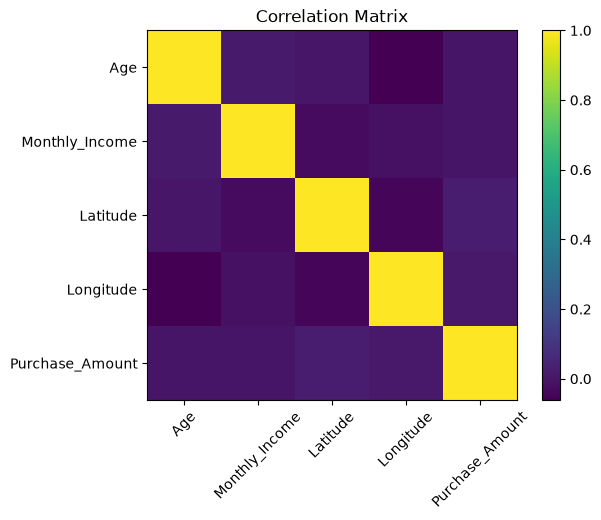

In [36]:
plt.imshow(correlation)

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")
plt.colorbar()

plt.show()